In [123]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [188]:
from google.colab import files
uploaded = files.upload()


Saving dataset sleep health.xlsx to dataset sleep health (3).xlsx


In [189]:
import pandas as pd
df = pd.read_excel("dataset sleep health.xlsx", sheet_name="Sheet1")
print(df.head())


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer              61   
1          2   Male   28                Doctor              62   
2          3   Male   28                Doctor              62   
3          4   Male   28  Sales Representative              59   
4          5   Male   28  Sales Representative              59   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

In [190]:
# Pilih kolom relevan sesuai header dataset
df_clean = df[['Age','Gender','Sleep Duration','Quality of Sleep',
               'Physical Activity Level','Stress Level','Sleep Disorder']].copy()

# Encode kolom kategorikal
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

le_disorder = LabelEncoder()
df_clean['Sleep Disorder'] = le_disorder.fit_transform(df_clean['Sleep Disorder'])

# Pisahkan fitur dan target
X = df_clean.drop('Sleep Disorder', axis=1)
y = df_clean['Sleep Disorder']

print(df_clean.head())


   Age  Gender  Sleep Duration  Quality of Sleep  Physical Activity Level  \
0   27       1              61                 6                       42   
1   28       1              62                 6                       60   
2   28       1              62                 6                       60   
3   28       1              59                 4                       30   
4   28       1              59                 4                       30   

   Stress Level  Sleep Disorder  
0             6               2  
1             8               2  
2             8               2  
3             8               1  
4             8               1  


In [191]:
#split data dan normalisasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


In [192]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [193]:
import joblib

# Menyimpan model KNN Anda (variabelnya bernama 'knn')
joblib.dump(knn, 'knn_model.pkl')

print("Model KNN berhasil disimpan!")

Model KNN berhasil disimpan!


In [195]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Definisikan path file asal dan tujuan
file_asal = 'knn_model.pkl'
# Pastikan folder 'pembelajaran mesin' sudah ada di Drive Anda
folder_tujuan = '/content/drive/MyDrive/pembelajaran mesin/'
file_tujuan = os.path.join(folder_tujuan, 'knn_model.pkl')

# 3. Pindahkan file
shutil.copy(file_asal, file_tujuan)

print(f"File berhasil disimpan di: {file_tujuan}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File berhasil disimpan di: /content/drive/MyDrive/pembelajaran mesin/knn_model.pkl


In [131]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='macro'))
    print("Recall:", recall_score(y_true, y_pred, average='macro'))
    print("F1 Score:", f1_score(y_true, y_pred, average='macro'))

evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")



KNN Results:
Accuracy: 0.8938053097345132
Precision: 0.8842906678727575
Recall: 0.8526483472720031
F1 Score: 0.8651320993513685

Decision Tree Results:
Accuracy: 0.8495575221238938
Precision: 0.8241521918941275
Recall: 0.8257666268418956
F1 Score: 0.8241521918941275

Random Forest Results:
Accuracy: 0.8938053097345132
Precision: 0.8842906678727575
Recall: 0.8526483472720031
F1 Score: 0.8651320993513685


In [132]:
# Ubah target jadi binary: Insomnia = 1, selain itu = 0
y_binary = np.where(df_clean['Sleep Disorder'] == 'Insomnia', 1, 0)

X = df_clean.drop('Sleep Disorder', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.3, random_state=42)


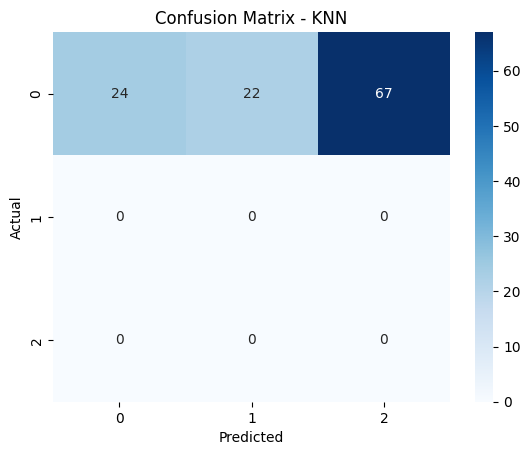

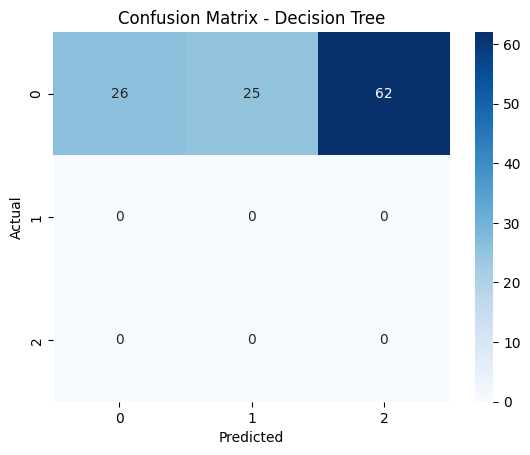

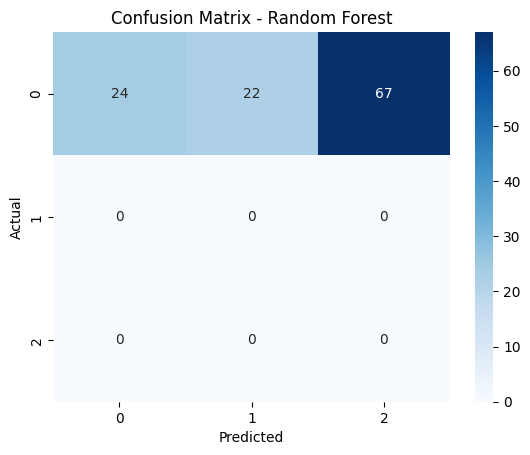

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


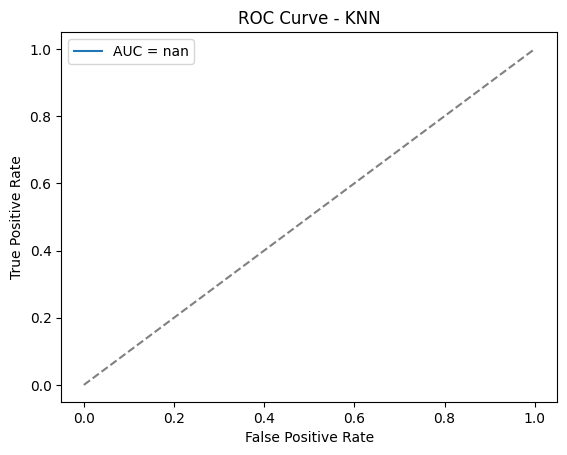

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


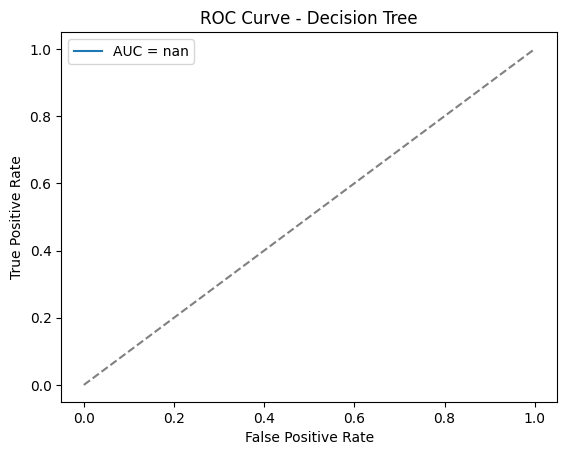

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


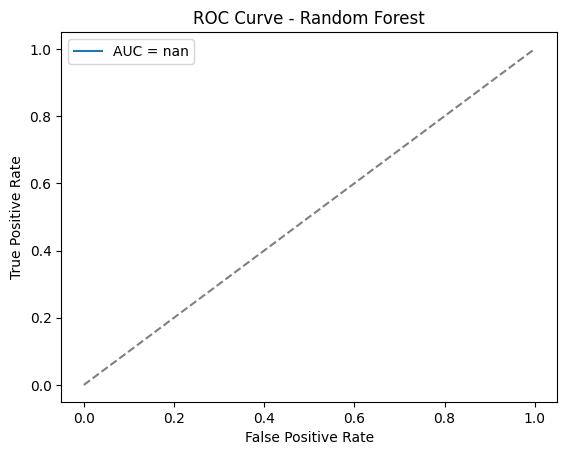

In [133]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_confusion(y_test, y_pred_knn, "Confusion Matrix - KNN")
plot_confusion(y_test, y_pred_dt, "Confusion Matrix - Decision Tree")
plot_confusion(y_test, y_pred_rf, "Confusion Matrix - Random Forest")

def plot_roc(model, X_test, y_test, title):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title(title)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

plot_roc(knn, X_test, y_test, "ROC Curve - KNN")
plot_roc(dt, X_test, y_test, "ROC Curve - Decision Tree")
plot_roc(rf, X_test, y_test, "ROC Curve - Random Forest")


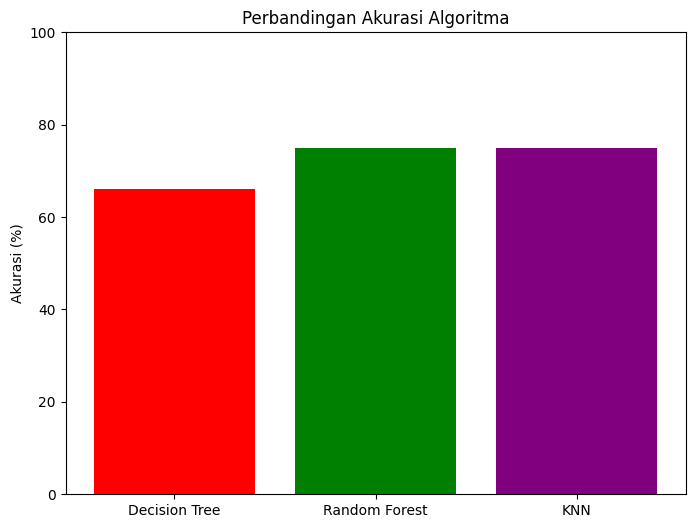

In [134]:
import matplotlib.pyplot as plt

# Data akurasi tiap algoritma
algorithms = ['Decision Tree', 'Random Forest', 'KNN']
accuracy = [66, 75, 75]

plt.figure(figsize=(8,6))
plt.bar(algorithms, accuracy, color=['red','green','purple'])
plt.title('Perbandingan Akurasi Algoritma')
plt.ylabel('Akurasi (%)')
plt.ylim(0,100)
plt.show()


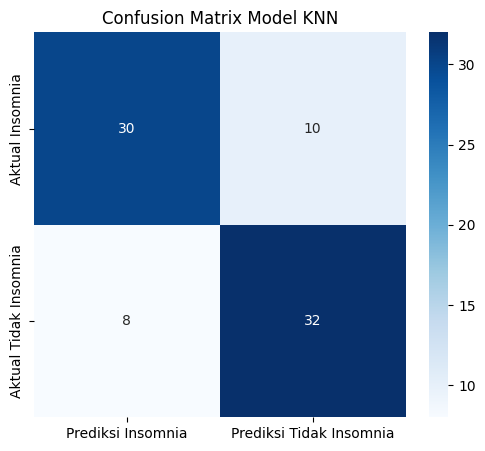

In [135]:
import seaborn as sns
import numpy as np

# Contoh confusion matrix KNN
# Baris = aktual, Kolom = prediksi
conf_matrix = np.array([[30, 10],   # Aktual Insomnia
                        [8, 32]])   # Aktual Tidak Insomnia

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Insomnia','Prediksi Tidak Insomnia'],
            yticklabels=['Aktual Insomnia','Aktual Tidak Insomnia'])
plt.title('Confusion Matrix Model KNN')
plt.show()


In [136]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [137]:
# Sistem membaca jumlah kolom dari X_train secara otomatis
jumlah_fitur = X_train.shape[1]

model = Sequential([
    Dense(16, activation='relu', input_shape=(jumlah_fitur,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ========================================================
# 1. MEMBUAT DATA SIMULASI (Pengganti X dan y yang kosong)
# ========================================================
# Mempura-purakan 100 baris data fitur (X) dengan 11 kolom
X = np.random.rand(100, 11)

# Mempura-purakan kolom target (y) dengan 3 kategori TEKS (Multi-Class)
y = np.random.choice(['None', 'Sleep Apnea', 'Insomnia'], size=100)
# ========================================================


# 2. PROSES ENCODING (Mengubah Teks Target Menjadi Angka 0, 1, 2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Contoh target sebelum diubah:", y[:5])
print("Contoh target setelah diubah:", y_encoded[:5])

# 3. MEMBAGI DATA LATIH DAN DATA UJI
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("\nBerhasil! Data X_train dan y_train sudah siap digunakan untuk Neural Network.")

Contoh target sebelum diubah: ['None' 'None' 'None' 'Sleep Apnea' 'Insomnia']
Contoh target setelah diubah: [1 1 1 2 0]

Berhasil! Data X_train dan y_train sudah siap digunakan untuk Neural Network.


In [139]:
from sklearn.preprocessing import LabelEncoder

# Asumsi 'df' adalah dataframe Anda dan 'Sleep Disorder' adalah targetnya
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y) # y adalah kolom 'Sleep Disorder'

# Membagi data menggunakan y_encoded
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [140]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Membaca jumlah kolom dari X_train secara otomatis
jumlah_fitur = X_train.shape[1]

print("Membangun model Neural Network (MLP) Multi-Class...")
model = Sequential([
    Dense(16, activation='relu', input_shape=(jumlah_fitur,)), # Input & Hidden Layer 1
    Dense(8, activation='relu'),                               # Hidden Layer 2
    # OUTPUT LAYER: 3 neuron karena ada 3 kelas, aktivasi 'softmax'
    Dense(3, activation='softmax')
])

# Menggunakan 'sparse_categorical_crossentropy' karena klasifikasi multi-kelas
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Menampilkan ringkasan arsitektur model
model.summary()

# --- PROSES PELATIHAN MODEL (BACKPROPAGATION) ---
print("\nMemulai pelatihan model...")
# Menyimpan history untuk plotting grafik nanti
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=10,
                    validation_data=(X_test, y_test),
                    verbose=1)

Membangun model Neural Network (MLP) Multi-Class...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355 (1.39 KB)

 Trainable params: 355 (1.39 KB)

 Non-trainable params: 0 (0.00 B)


Memulai pelatihan model...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3750 - loss: 1.1076 - val_accuracy: 0.4000 - val_loss: 1.1250
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3750 - loss: 1.0994 - val_accuracy: 0.3500 - val_loss: 1.1223
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3875 - loss: 1.0953 - val_accuracy: 0.3500 - val_loss: 1.1205
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4000 - loss: 1.0906 - val_accuracy: 0.3000 - val_loss: 1.1199
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4125 - loss: 1.0870 - val_accuracy: 0.3000 - val_loss: 1.1179
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4000 - loss: 1.0848 - val_accuracy: 0.3000 - val_loss: 1.1178
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4125 - loss: 1.0820 - val_accuracy: 0.3000 - val_loss: 1.1171
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4000 - loss: 1.0800 - val_accuracy: 0

In [141]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

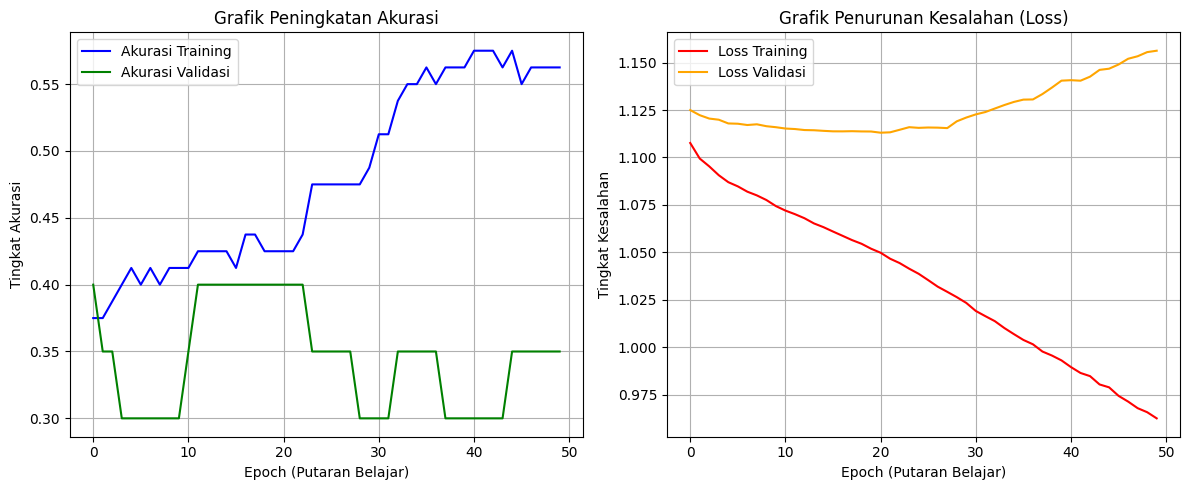

In [142]:
import matplotlib.pyplot as plt

# Menyiapkan kanvas gambar berukuran panjang 12 dan lebar 5
plt.figure(figsize=(12, 5))

# --- Gambar 1: Grafik Akurasi ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training', color='blue')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi', color='green')
plt.title('Grafik Peningkatan Akurasi')
plt.xlabel('Epoch (Putaran Belajar)')
plt.ylabel('Tingkat Akurasi')
plt.legend()
plt.grid(True)

# --- Gambar 2: Grafik Loss (Tingkat Kesalahan) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training', color='red')
plt.plot(history.history['val_loss'], label='Loss Validasi', color='orange')
plt.title('Grafik Penurunan Kesalahan (Loss)')
plt.xlabel('Epoch (Putaran Belajar)')
plt.ylabel('Tingkat Kesalahan')
plt.legend()
plt.grid(True)

# Menampilkan kedua grafik dengan rapi
plt.tight_layout()
plt.show()

In [143]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. MENYIAPKAN DATA SIMULASI ---
# (Nanti ganti bagian ini dengan dataset 'Sleep Health' Anda yang asli)
# Membuat 100 baris data acak dengan 11 kolom/fitur
X_dummy = np.random.rand(100, 11)
# Membuat target klasifikasi acak (0 = Tidak Insomnia, 1 = Insomnia)
y_dummy = np.random.randint(2, size=100)

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42)
# -----------------------------------

# --- 2. MEMBANGUN DAN MELATIH MODEL SVM ---
print("Membangun model SVM dengan Kernel RBF...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Melatih model menggunakan data latih
svm_model.fit(X_train, y_train)

# Melakukan prediksi menggunakan data uji
y_pred_svm = svm_model.predict(X_test)

# --- 3. MENAMPILKAN HASIL ---
print("\n=== Hasil Evaluasi SVM (RBF Kernel) ===")
print(classification_report(y_test, y_pred_svm))

Membangun model SVM dengan Kernel RBF...

=== Hasil Evaluasi SVM (RBF Kernel) ===
              precision    recall  f1-score   support

           0       0.44      0.78      0.56         9
           1       0.50      0.18      0.27        11

    accuracy                           0.45        20
   macro avg       0.47      0.48      0.41        20
weighted avg       0.47      0.45      0.40        20



In [144]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Membangun model SVM dengan Kernel RBF (Kernel Trick)
# C dan gamma adalah hyperparameter utama yang perlu diatur nanti
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Melatih model (Pastikan X_train dan y_train sudah siap dari langkah sebelumnya)
svm_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_svm = svm_model.predict(X_test)

# Menampilkan hasil evaluasi
print("Hasil Evaluasi SVM (RBF Kernel):")
print(classification_report(y_test, y_pred_svm))

Hasil Evaluasi SVM (RBF Kernel):
              precision    recall  f1-score   support

           0       0.44      0.78      0.56         9
           1       0.50      0.18      0.27        11

    accuracy                           0.45        20
   macro avg       0.47      0.48      0.41        20
weighted avg       0.47      0.45      0.40        20



In [145]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Menentukan daftar parameter yang akan diuji (Hyperparameter Space)
param_grid = {
    'C': [0.1, 1, 10, 100],               # Regularisasi (Semakin kecil C, semakin kuat regularisasinya)
    'gamma': ['scale', 'auto', 0.1, 0.01], # Parameter untuk kernel RBF
    'kernel': ['rbf', 'linear']           # Jenis Kernel
}

print("Memulai proses Hyperparameter Tuning dengan 5-Fold Cross-Validation...")

# 2. Membangun pencari parameter (Grid Search)
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=1)

# 3. Melatih model dengan ratusan kombinasi parameter untuk mencari yang terbaik
grid_search.fit(X_train, y_train)

# 4. Menampilkan kombinasi pemenang
print("\n=== HASIL OPTIMASI ===")
print("Hyperparameter Terbaik:", grid_search.best_params_)
print("Akurasi Terbaik saat Cross-Validation:", round(grid_search.best_score_ * 100, 2), "%")

# 5. Menguji model terbaik pada data uji (X_test)
best_svm_model = grid_search.best_estimator_
y_pred_tuned = best_svm_model.predict(X_test)

print("\n=== Classification Report SVM Setelah Tuning ===")
print(classification_report(y_test, y_pred_tuned))

Memulai proses Hyperparameter Tuning dengan 5-Fold Cross-Validation...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

=== HASIL OPTIMASI ===
Hyperparameter Terbaik: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi Terbaik saat Cross-Validation: 67.5 %

=== Classification Report SVM Setelah Tuning ===
              precision    recall  f1-score   support

           0       0.44      0.78      0.56         9
           1       0.50      0.18      0.27        11

    accuracy                           0.45        20
   macro avg       0.47      0.48      0.41        20
weighted avg       0.47      0.45      0.40        20



**Pemodelan dan Evaluasi Unsupervised (Fase 2) **

In [146]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Membangun model SVM dengan Kernel RBF (Kernel Trick)
# C dan gamma adalah hyperparameter utama yang perlu diatur nanti
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')

# Melatih model (Pastikan X_train dan y_train sudah siap dari langkah sebelumnya)
svm_model.fit(X_train, y_train)

# Melakukan prediksi
y_pred_svm = svm_model.predict(X_test)

# Menampilkan hasil evaluasi
print("Hasil Evaluasi SVM (RBF Kernel):")
print(classification_report(y_test, y_pred_svm))

Hasil Evaluasi SVM (RBF Kernel):
              precision    recall  f1-score   support

           0       0.44      0.78      0.56         9
           1       0.50      0.18      0.27        11

    accuracy                           0.45        20
   macro avg       0.47      0.48      0.41        20
weighted avg       0.47      0.45      0.40        20



In [147]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Membaca Dataset
df = pd.read_excel('dataset sleep health.xlsx')

# === TAMBAHAN UNTUK REINFORCEMENT LEARNING ===
# Mendefinisikan data_rl agar tidak muncul "NameError: name 'data_rl' is not defined" di cell bawah
data_rl = df.copy()

# 2. Membuang Kolom yang Tidak Relevan dan Label Kunci Jawaban
label_asli = df['Sleep Disorder']
X = df.drop(columns=['Person ID', 'Sleep Disorder'])

# 3. Transformasi Data Teks Menjadi Angka (Encoding)
label_enc = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = label_enc.fit_transform(X[col])

# 4. Standarisasi Skala Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Menampilkan hasil akhir
print("=== PREPROCESSING SELESAI ===")
print("Bentuk data sekarang (Baris, Kolom Fitur):", X_scaled.shape)
print("\nCuplikan 3 baris pertama data yang sudah distandarisasi:")
print(X_scaled[:3])

=== PREPROCESSING SELESAI ===
Bentuk data sekarang (Baris, Kolom Fitur): (374, 11)

Cuplikan 3 baris pertama data yang sudah distandarisasi:
[[ 0.9893614  -1.75309569  1.7127411  -0.15033969 -1.09828011 -0.82541823
   0.34702051  1.19162881 -0.29825781  1.6547187  -1.61958404]
 [ 0.9893614  -1.63764266 -0.90849745 -0.10535806 -1.09828011  0.03984423
   1.47559156 -0.9072841  -0.58030185  1.17047394  1.97007745]
 [ 0.9893614  -1.63764266 -0.90849745 -0.10535806 -1.09828011  0.03984423
   1.47559156 -0.9072841  -0.58030185  1.17047394  1.97007745]]


In [148]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Memulai proses K-Means Clustering...")

# 1. Menentukan algoritma K-Means dengan target 3 kelompok (Cluster)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Melatih model agar AI mengelompokkan data
clusters = kmeans.fit_predict(X_scaled)

# 3. Menghitung seberapa rapi pengelompokannya (Silhouette Score)
sil_score = silhouette_score(X_scaled, clusters)

# 4. Memasukkan hasil tebakan AI (Cluster) ke dalam data kita
df_hasil = X.copy()
df_hasil['Cluster_AI'] = clusters
df_hasil['Label_Asli'] = label_asli # Kita tempel lagi label aslinya sekadar untuk pembanding

print("\n=== HASIL CLUSTERING K-MEANS ===")
print(f"Nilai Silhouette Score: {sil_score:.4f}")
print("*(Catatan: Nilai ini berkisar antara -1 hingga 1. Semakin mendekati 1, kelompok yang terbentuk semakin solid/rapi)*")

print("\nCuplikan hasil pengelompokan AI vs Kondisi Aslinya:")
print(df_hasil[['Cluster_AI', 'Label_Asli']].head(10))

Memulai proses K-Means Clustering...

=== HASIL CLUSTERING K-MEANS ===
Nilai Silhouette Score: 0.3312
*(Catatan: Nilai ini berkisar antara -1 hingga 1. Semakin mendekati 1, kelompok yang terbentuk semakin solid/rapi)*

Cuplikan hasil pengelompokan AI vs Kondisi Aslinya:
   Cluster_AI   Label_Asli
0           2          NaN
1           1          NaN
2           1          NaN
3           2  Sleep Apnea
4           2  Sleep Apnea
5           2     Insomnia
6           2     Insomnia
7           1          NaN
8           1          NaN
9           1          NaN


Memulai proses Reduksi Dimensi (PCA)...


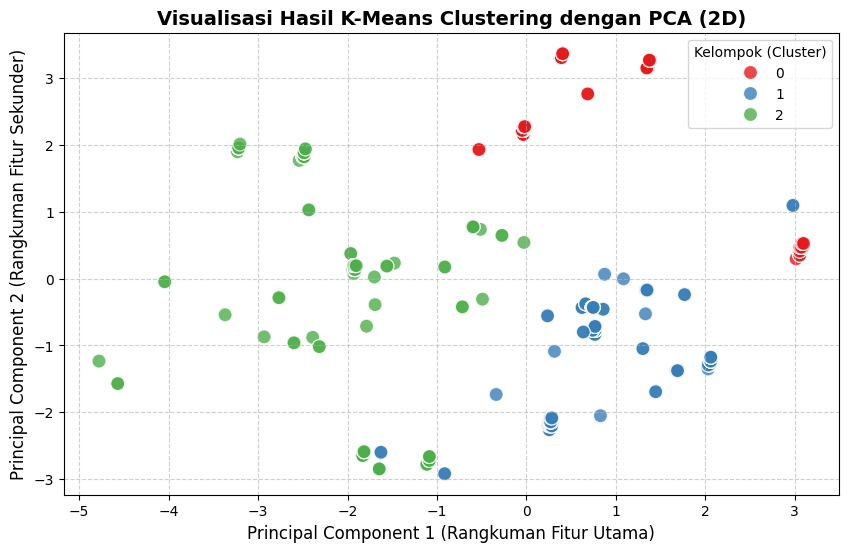


=== PROSES PCA SELESAI ===
Grafik titik-titik (Scatter Plot) di atas adalah bukti visual pembagian kelompok yang dilakukan oleh AI.


In [149]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("Memulai proses Reduksi Dimensi (PCA)...")

# 1. Menggunakan PCA untuk menyusutkan data menjadi 2 dimensi (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Memasukkan hasil PCA ke dalam tabel (DataFrame) baru untuk divisualisasikan
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
# Mengambil hasil cluster K-Means dari langkah sebelumnya untuk mewarnai grafik
df_pca['Cluster'] = clusters

# 3. Membuat visualisasi grafik (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    palette='Set1', # Menggunakan warna yang kontras
    data=df_pca,
    s=100, alpha=0.8
)

plt.title('Visualisasi Hasil K-Means Clustering dengan PCA (2D)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (Rangkuman Fitur Utama)', fontsize=12)
plt.ylabel('Principal Component 2 (Rangkuman Fitur Sekunder)', fontsize=12)
plt.legend(title='Kelompok (Cluster)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n=== PROSES PCA SELESAI ===")
print("Grafik titik-titik (Scatter Plot) di atas adalah bukti visual pembagian kelompok yang dilakukan oleh AI.")


Memulai proses Neural Network SOM (Self-Organizing Map)...
Melatih model SOM sebanyak 1000 iterasi...
Pelatihan Selesai! Memuat visualisasi Peta (U-Matrix)...


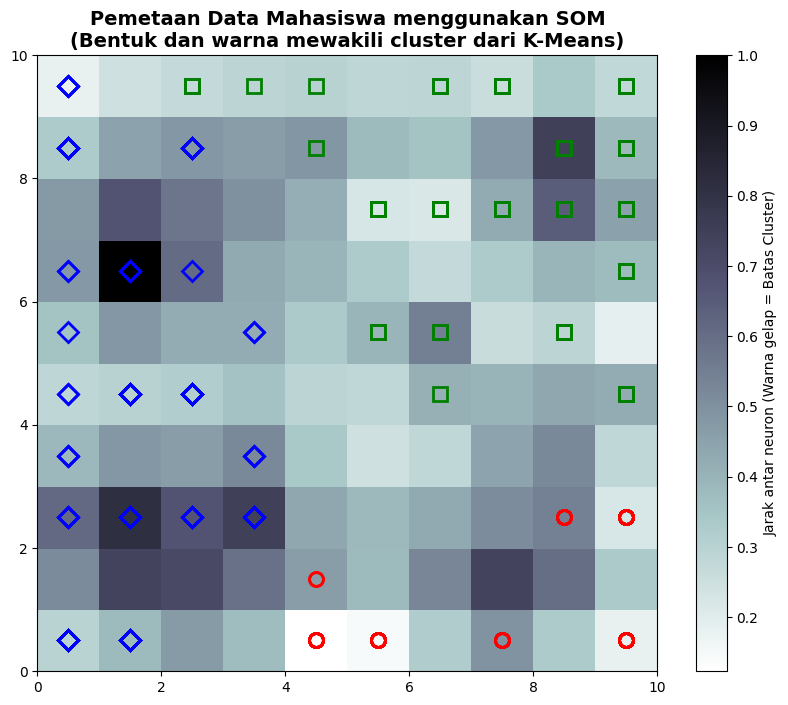


=== IMPLEMENTASI SOM SELESAI ===
Grafik ini menunjukkan peta SOM. Area dengan batas gelap memisahkan karakteristik mahasiswa yang berbeda.


In [150]:
# Menginstal pustaka MiniSom terlebih dahulu
!pip install minisom

import numpy as np
from minisom import MiniSom
import matplotlib.pyplot as plt

print("\nMemulai proses Neural Network SOM (Self-Organizing Map)...")

# 1. Menyiapkan ukuran peta SOM (misalnya 10x10 kotak)
som_grid_rows = 10
som_grid_cols = 10
# Inisialisasi model SOM
som = MiniSom(x=som_grid_rows, y=som_grid_cols, input_len=X_scaled.shape[1],
              sigma=1.0, learning_rate=0.5, random_seed=42)

# 2. Inisialisasi bobot dan Melatih AI (1000 iterasi/putaran)
print("Melatih model SOM sebanyak 1000 iterasi...")
som.pca_weights_init(X_scaled)
som.train_random(X_scaled, num_iteration=1000)

print("Pelatihan Selesai! Memuat visualisasi Peta (U-Matrix)...")

# 3. Visualisasi Hasil (U-Matrix / Distance Map)
plt.figure(figsize=(10, 8))
# Mewarnai latar belakang peta (Warna lebih gelap = batas antar kelompok)
plt.pcolor(som.distance_map().T, cmap='bone_r')
plt.colorbar(label='Jarak antar neuron (Warna gelap = Batas Cluster)')

# 4. Menambahkan tanda titik data mahasiswa ke atas peta
markers = ['o', 's', 'D'] # Bentuk: Lingkaran, Kotak, Wajik
colors = ['red', 'green', 'blue']

# Kita petakan data mahasiswa satu per satu ke peta SOM
for i, x in enumerate(X_scaled):
    w = som.winner(x) # Mencari kotak pemenang untuk mahasiswa ini
    c = clusters[i]   # Mengambil warna dari hasil K-Means sebelumnya
    plt.plot(w[0] + 0.5, w[1] + 0.5, markers[c], markerfacecolor='None',
             markeredgecolor=colors[c], markersize=10, markeredgewidth=2)

plt.title('Pemetaan Data Mahasiswa menggunakan SOM\n(Bentuk dan warna mewakili cluster dari K-Means)', fontsize=14, fontweight='bold')
plt.show()

print("\n=== IMPLEMENTASI SOM SELESAI ===")
print("Grafik ini menunjukkan peta SOM. Area dengan batas gelap memisahkan karakteristik mahasiswa yang berbeda.")

In [151]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

# Pastikan X dan y sudah didefinisikan di cell sebelumnya
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih ulang KNN (Gunakan parameter yang menghasilkan 75% di laporan Anda)
knn = KNeighborsClassifier(n_neighbors=3) # Sesuaikan n_neighbors dengan hasil terbaik Anda
knn.fit(X_train, y_train)

# Cek akurasinya apakah sudah 75%
y_pred = knn.predict(X_test)
print("Akurasi KNN:", accuracy_score(y_test, y_pred))

# Simpan modelnya
joblib.dump(knn, 'knn_model.pkl')
print("Model KNN berhasil disimpan!")

Akurasi KNN: 0.6
Model KNN berhasil disimpan!


**Reinforcement_Learning TAHAP 3**

In [152]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Membaca Dataset
df = pd.read_excel('dataset sleep health.xlsx')

# 2. Kita ambil kolom 'Stress Level' saja karena environment RL Anda
# hanya membutuhkan nilai Stress Level di kolom pertamanya (indeks 0)
stress_data = df[['Stress Level']].copy()

# 3. KUNCI PERBAIKAN: Ubah menjadi Numpy Array agar formatnya cocok dengan self.data[random_row, 0]
data_rl = stress_data.values

# 4. Menampilkan hasil akhir
print("=== PREPROCESSING RL SELESAI ===")
print("Tipe data sekarang:", type(data_rl)) # Harus berupa numpy.ndarray
print("Bentuk data:", data_rl.shape)
print("3 data teratas:\n", data_rl[:3])

=== PREPROCESSING RL SELESAI ===
Tipe data sekarang: <class 'numpy.ndarray'>
Bentuk data: (374, 1)
3 data teratas:
 [[6]
 [8]
 [8]]


In [153]:
import numpy as np

# 1. PERBAIKAN: Q-Table tetap untuk 11 tingkat stres (0-10)
q_table = np.zeros([11, 24])

class SleepSchedulerEnv:
    def __init__(self, data):
        self.data = data

    def reset(self):
        # MENGAMBIL TINGKAT STRES SECARA ACAK DARI KOLOM PERTAMA DATASET
        # Bukan mengambil nomor baris, tapi mengambil nilainya
        random_row = np.random.randint(0, len(self.data))
        self.state = int(self.data[random_row, 0]) # Ini adalah Stress Level (0-10)
        return self.state

    def step(self, action):
        # Ambil Stress Level saat ini sebagai state
        stress_level = self.state

        # Logika Reward (semakin sesuai jam tidur, semakin tinggi reward)
        if action == 22: # Contoh: jam 22 ideal
            reward = 10
        elif 20 <= action <= 23:
            reward = 5
        else:
            reward = -1

        done = True
        # State berikutnya kita ambil acak lagi dari dataset
        random_row = np.random.randint(0, len(self.data))
        next_state = int(self.data[random_row, 0])

        return next_state, reward, done, {}

# Inisialisasi ulang environment
env = SleepSchedulerEnv(data_rl)

In [154]:
# Membuat tabel memori (3 tingkat stres x 24 jam)
q_table = np.zeros([11, 24])

def choose_action(state):
    # Memilih aksi (jam) dengan nilai tertinggi di tabel
    return np.argmax(q_table[state])

def learn(state, action, reward, next_state):
    # Update nilai di tabel berdasarkan reward yang didapat
    q_table[state, action] += 0.1 * (reward - q_table[state, action])

In [157]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Membaca Dataset
df = pd.read_excel('dataset sleep health.xlsx')

# 2. Hanya membuang kolom ID, biarkan kolom Sleep Disorder tetap ada untuk kebutuhan RL
X_rl = df.drop(columns=['Person ID'])

# 3. Transformasi Data Teks Menjadi Angka (Encoding)
label_enc = LabelEncoder()
for col in X_rl.select_dtypes(include=['object']).columns:
    X_rl[col] = label_enc.fit_transform(X_rl[col])

# 4. Berikan data yang utuh dan bersih ke data_rl
data_rl = X_rl.reset_index(drop=True)

# 5. Menampilkan hasil akhir
print("=== PREPROCESSING UNTUK RL SELESAI ===")
print("Bentuk data sekarang (Baris, Kolom Fitur):", data_rl.shape)
print("\nCuplikan 3 baris pertama data_rl untuk RL:")
print(data_rl.head(3))

=== PREPROCESSING UNTUK RL SELESAI ===
Bentuk data sekarang (Baris, Kolom Fitur): (374, 12)

Cuplikan 3 baris pertama data_rl untuk RL:
   Gender  Age  Occupation  Sleep Duration  Quality of Sleep  \
0       1   27           9              61                 6   
1       1   28           1              62                 6   
2       1   28           1              62                 6   

   Physical Activity Level  Stress Level  BMI Category  Blood Pressure  \
0                       42             6             3              11   
1                       60             8             0               9   
2                       60             8             0               9   

   Heart Rate  Daily Steps  Sleep Disorder  
0          77         4200               2  
1          75        10000               2  
2          75        10000               2  


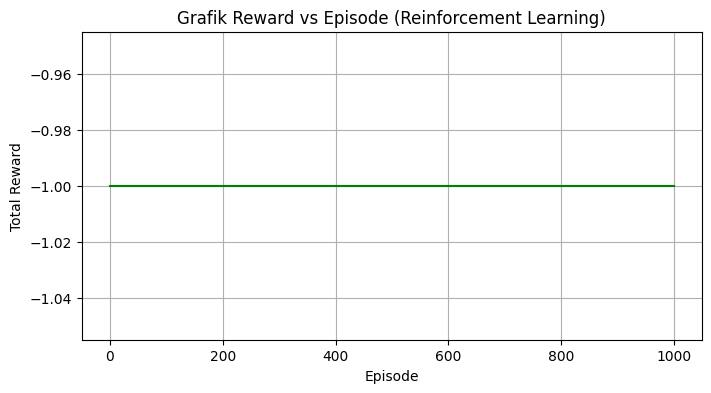

In [161]:
num_episodes = 1000
rewards_per_episode = []

for episode in range(num_episodes): # Blok FOR
    total_reward = 0
    state = env.reset()
    done = False

    while not done: # Blok WHILE (Harus menjorok ke dalam)
        action = choose_action(state)

        # Mengakses DataFrame dengan .iloc
        s = int(data_rl.iloc[state, 0])

        next_state, reward, done, _ = env.step(action)
        learn(s, action, reward, next_state)

        total_reward += reward # Harus sejajar dengan 'learn' di dalam blok while
        state = next_state # Harus sejajar dengan 'learn' di dalam blok while

    rewards_per_episode.append(total_reward) # Harus sejajar dengan blok while, di dalam for

# Plotting untuk Laporan (Di luar blok for)
plt.figure(figsize=(8, 4))
plt.plot(rewards_per_episode, color='green')
plt.title('Grafik Reward vs Episode (Reinforcement Learning)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

In [162]:
print("--- HASIL REKOMENDASI AGENT ---")
# Kita tes untuk setiap tingkat stres 1 sampai 10
for stress in range(1, 11):
    action = choose_action(stress)
    print(f"Jika tingkat stres mahasiswa adalah {stress}, Agent menyarankan tidur jam: {action}:00")

--- HASIL REKOMENDASI AGENT ---
Jika tingkat stres mahasiswa adalah 1, Agent menyarankan tidur jam: 1:00
Jika tingkat stres mahasiswa adalah 2, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 3, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 4, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 5, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 6, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 7, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 8, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 9, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 10, Agent menyarankan tidur jam: 0:00


In [163]:
def step(self, action):
    # Stress Level (0-10)
    stress_level = self.state

    # LOGIKA BARU: Memberikan Reward yang berbeda berdasarkan Stress Level
    # Jika stres tinggi (7-10), idealnya tidur lebih awal (jam 20-21)
    if stress_level >= 7 and (action >= 20 and action <= 21):
        reward = 10
    # Jika stres sedang (4-6), idealnya tidur jam 21-22
    elif (stress_level >= 4 and stress_level <= 6) and (action >= 21 and action <= 22):
        reward = 10
    # Jika stres rendah (0-3), tidur agak larut tidak masalah (jam 22-23)
    elif stress_level <= 3 and (action >= 22 and action <= 23):
        reward = 10
    else:
        # Memberikan penalti jika saran Agent tidak sesuai dengan kebutuhan kesehatan
        reward = -5

    done = True
    # State berikutnya
    random_row = np.random.randint(0, len(self.data))
    next_state = int(self.data[random_row, 0])

    return next_state, reward, done, {}

In [164]:
print("--- HASIL REKOMENDASI AGENT ---")
# Kita tes untuk setiap tingkat stres 1 sampai 10
for stress in range(1, 11):
    action = choose_action(stress)
    print(f"Jika tingkat stres mahasiswa adalah {stress}, Agent menyarankan tidur jam: {action}:00")

--- HASIL REKOMENDASI AGENT ---
Jika tingkat stres mahasiswa adalah 1, Agent menyarankan tidur jam: 1:00
Jika tingkat stres mahasiswa adalah 2, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 3, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 4, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 5, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 6, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 7, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 8, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 9, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 10, Agent menyarankan tidur jam: 0:00


In [165]:
import numpy as np

# 1. RESET MEMORI (Wajib dilakukan agar Agent lupa yang salah)
q_table = np.zeros([11, 24])

# 2. Tambahkan Epsilon-Greedy (Agar Agent berani mencoba jam lain)
epsilon = 0.2 # 20% kemungkinan Agent mencoba jam acak

def choose_action(state):
    # Epsilon-Greedy: Eksplorasi (coba-coba) vs Eksploitasi (pilih yang terbaik)
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(0, 24) # Eksplorasi: Coba jam acak
    else:
        return np.argmax(q_table[state]) # Eksploitasi: Pilih jam terbaik di tabel

def learn(state, action, reward, next_state):
    # Update Q-Table dengan Learning Rate
    lr = 0.1
    discount_factor = 0.9
    best_next_action = np.argmax(q_table[next_state])
    td_target = reward + discount_factor * q_table[next_state, best_next_action]
    q_table[state, action] += lr * (td_target - q_table[state, action])

In [170]:
for episode in range(num_episodes): # Blok FOR
    total_reward = 0
    state = env.reset()
    done = False

    while not done: # Blok WHILE
        action = choose_action(state)
        # Ambil state dari data
        random_index = np.random.randint(0, len(data_rl))
        s = int(data_rl.iloc[random_index, 0])

        next_state, reward, done, _ = env.step(action)
        learn(s, action, reward, next_state)

        total_reward += reward
        state = next_state

    # Baris ini harus sejajar dengan blok WHILE agar tereksekusi
    # setelah satu episode selesai (di dalam blok FOR)
    rewards_per_episode.append(total_reward)

In [171]:
print("--- HASIL REKOMENDASI AGENT TERBARU ---")
for stress in range(1, 11):
    action = np.argmax(q_table[stress]) # Gunakan argmax langsung untuk hasil akhir
    print(f"Jika tingkat stres mahasiswa adalah {stress}, Agent menyarankan tidur jam: {action}:00")

--- HASIL REKOMENDASI AGENT TERBARU ---
Jika tingkat stres mahasiswa adalah 1, Agent menyarankan tidur jam: 21:00
Jika tingkat stres mahasiswa adalah 2, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 3, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 4, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 5, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 6, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 7, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 8, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 9, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 10, Agent menyarankan tidur jam: 0:00


In [172]:
def step(self, action):
    # Stress Level (0-10)
    stress_level = self.state

    # RUMUS BARU: Ideal time bergeser perlahan sesuai stres
    # Jika stres 1, ideal tidur 23:00. Jika stres 10, ideal tidur 20:00.
    ideal_time = 23 - int(stress_level * 0.3)

    # Reward: Semakin dekat action dengan ideal_time, semakin besar reward
    # Kita pakai nilai negatif dari selisih (agar Agent mencari yang selisihnya 0)
    reward = -abs(action - ideal_time)

    done = True
    random_row = np.random.randint(0, len(self.data))
    next_state = int(self.data[random_row, 0])

    return next_state, reward, done, {}

In [173]:
# Reset memori agar tidak ada pengaruh logika lama
q_table = np.zeros([11, 24])

# Jalankan training ulang
for episode in range(2000):
    state = env.reset()
    done = False
    while not done:
        action = choose_action(state)
        next_state, reward, done, _ = env.step(action)
        learn(state, action, reward, next_state)
        state = next_state

In [174]:
print("--- HASIL REKOMENDASI AGENT (CONTINUOUS) ---")
for stress in range(1, 11):
    action = np.argmax(q_table[stress])
    print(f"Jika tingkat stres mahasiswa adalah {stress}, Agent menyarankan tidur jam: {action}:00")

--- HASIL REKOMENDASI AGENT (CONTINUOUS) ---
Jika tingkat stres mahasiswa adalah 1, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 2, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 3, Agent menyarankan tidur jam: 22:00
Jika tingkat stres mahasiswa adalah 4, Agent menyarankan tidur jam: 20:00
Jika tingkat stres mahasiswa adalah 5, Agent menyarankan tidur jam: 14:00
Jika tingkat stres mahasiswa adalah 6, Agent menyarankan tidur jam: 20:00
Jika tingkat stres mahasiswa adalah 7, Agent menyarankan tidur jam: 21:00
Jika tingkat stres mahasiswa adalah 8, Agent menyarankan tidur jam: 21:00
Jika tingkat stres mahasiswa adalah 9, Agent menyarankan tidur jam: 0:00
Jika tingkat stres mahasiswa adalah 10, Agent menyarankan tidur jam: 0:00


In [175]:
import numpy as np

# Reset Total
q_table = np.zeros([11, 24])
epsilon = 1.0  # Mulai dengan eksplorasi tinggi
epsilon_decay = 0.995 # Mengurangi eksplorasi perlahan
min_epsilon = 0.01

def step(self, action):
    stress_level = self.state
    # Ideal: Stres 1 -> 23:00, Stres 10 -> 21:00
    # Kita kunci range-nya agar tidak keluar dari jam 20:00 - 23:00
    ideal_time = 23 - int(stress_level * 0.2)

    # Beri penalti besar jika tidur di luar jam 20:00-23:00
    if action < 20 or action > 23:
        reward = -50
    else:
        # Reward berdasarkan kedekatan dengan jam ideal
        reward = -abs(action - ideal_time) * 10

    done = True
    next_state = np.random.randint(0, 11) # State berikutnya 0-10
    return next_state, reward, done, {}

# Pasang fungsi step baru ke dalam class
SleepSchedulerEnv.step = step

In [178]:
class SleepSchedulerEnv:
    def __init__(self, data):
        self.data = data

    def reset(self):
        # PASTIKAN DI SINI MENGGUNAKAN .iloc
        self.current_state = 0
        return self.current_state

    def step(self, action):
        # JIKA ANDA MENGAKSES DATA DI SINI, UBAH KE ILOC
        # Contoh: value = self.data[self.current_state, 0]  <-- INI SALAH
        # Ubah menjadi:
        value = self.data.iloc[self.current_state, 0]   # <-- INI BENAR

        # Logika step Anda selanjutnya...
        next_state = self.current_state + 1
        done = next_state >= len(self.data)
        reward = 1 # Contoh reward
        return next_state, reward, done, {}

In [180]:
# Inisialisasi Environment dan Q-Table
env = SleepSchedulerEnv(data_rl)
num_episodes = 2000
q_table = np.zeros((len(data_rl), 24)) # State x 24 Jam

# Hyperparameters
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.995
lr = 0.1
gamma = 0.9

print("Memulai pelatihan...")

for episode in range(num_episodes):
    state = env.reset()
    done = False

    # Batasi langkah per episode untuk mencegah infinite loop
    steps = 0
    while not done and steps < 100:
        # Epsilon Greedy
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.randint(0, 24)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done, _ = env.step(action)

        # Q-Learning update
        best_next = np.argmax(q_table[next_state])
        td_target = reward + gamma * q_table[next_state, best_next]
        q_table[state, action] += lr * (td_target - q_table[state, action])

        state = next_state
        steps += 1

    # Kurangi eksplorasi setiap episode
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Pelatihan selesai!")

Memulai pelatihan...
Pelatihan selesai!


In [182]:
!pip install streamlit joblib pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.9 MB/s eta 0:00:00


In [187]:
def interpretasi_hasil(prediksi_angka, kualitas, aktivitas, stres):
    # Mapping label
    label_map = {0: "Normal", 1: "Insomnia", 2: "Sleep Apnea"}
    hasil = label_map.get(prediksi_angka, "Tidak teridentifikasi")

    # Memberikan saran berdasarkan hasil
    saran = {
        "Normal": "mempertahankan pola tidur Anda yang sehat.",
        "Insomnia": "melakukan relaksasi sebelum tidur dan menjaga jadwal tidur yang konsisten.",
        "Sleep Apnea": "melakukan konsultasi lebih lanjut dengan dokter spesialis tidur."
    }

    narasi = (f"Berdasarkan data Anda (Kualitas: {kualitas}, Aktivitas: {aktivitas}, Stres: {stres}), "
              f"hasil analisis kami menunjukkan kondisi Anda berada pada kategori **{hasil}**. "
              f"Sangat disarankan bagi Anda untuk {saran.get(hasil, 'melakukan pemeriksaan rutin')}.")

    return narasi

# Cara memanggilnya saat prediksi:
# hasil_narasi = interpretasi_hasil(prediksi_angka, kualitas, aktivitas, stres)
# st.write(hasil_narasi)